## First step: train a Blackbox Model on the Penguin Data


In [1]:
import pandas as pd

data = pd.read_csv('penguins.csv')
data = data.dropna() # removes rows with NaN values. 333 datapoints remain.

print(data.info())

<class 'pandas.core.frame.DataFrame'>
Index: 333 entries, 0 to 343
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   rowid              333 non-null    int64  
 1   species            333 non-null    object 
 2   island             333 non-null    object 
 3   bill_length_mm     333 non-null    float64
 4   bill_depth_mm      333 non-null    float64
 5   flipper_length_mm  333 non-null    float64
 6   body_mass_g        333 non-null    float64
 7   sex                333 non-null    object 
 8   year               333 non-null    int64  
dtypes: float64(4), int64(2), object(3)
memory usage: 26.0+ KB
None


Some entries have NaN values for some features --> we should filter those. Some info is not relevant for us, e.g. the year of the observation. BUT it might also be interesting to see if a ML model uses the year to predict something even though it should not have an influence.

First, we try to predict the species only using numerical values in the dataset.

In [2]:
target = "species"

features = [
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g"
]

X = data[features]
Y = data[target]

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.35,              # which proportion of data is used for testing
    random_state=42,            # seed for random split generator in case data has ordering
    stratify=Y                  # class labels are chosen from here AND represented proportionnaly in both sets
)

In [4]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    #bootstrap = False,
)

model.fit(X_train, Y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

Now we have a trained Random Forest on our penguin data to predict the species of our penguins. 

In [5]:
# here we look at feature importance in the model, 
# i.e. how often the decision trees split over which feature.
importance = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=False)

print(importance)

bill_length_mm       0.440343
flipper_length_mm    0.261437
bill_depth_mm        0.206822
body_mass_g          0.091399
dtype: float64


In [6]:
from sklearn.metrics import classification_report

Y_pred = model.predict(X_test)
print(classification_report(Y_test, Y_pred))

              precision    recall  f1-score   support

      Adelie       1.00      0.96      0.98        51
   Chinstrap       0.92      1.00      0.96        24
      Gentoo       1.00      1.00      1.00        42

    accuracy                           0.98       117
   macro avg       0.97      0.99      0.98       117
weighted avg       0.98      0.98      0.98       117



In [7]:
#from sklearn.metrics import confusion_matrix
#import plotly.express as px
#
#cm = confusion_matrix(Y_test, Y_pred)
#
#labels = model.classes_
#
#fig = px.imshow(
#    cm,
#    x=labels,
#    y=labels,
#    text_auto=True,
#    aspect="auto",
#    labels={
#        "x": "Predicted",
#        "y": "Actual",
#        "color": "Number of penguins"
#    },
#    title="Confusion Matrix"
#)
#
#fig.show()

In [8]:
print(Y_test)

241       Gentoo
262       Gentoo
290    Chinstrap
261       Gentoo
196       Gentoo
         ...    
205       Gentoo
341    Chinstrap
305    Chinstrap
106       Adelie
223       Gentoo
Name: species, Length: 117, dtype: object


In [9]:
instance_idx=5


In [34]:
import lime.lime_tabular

class_names = ['Adelie', 'Chinstrap', 'Gentoo']

# Create the LIME explainer
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.to_numpy(),         # Data LIME uses to generate perturbations
    feature_names=features,   # List of feature names
    class_names=class_names,       # List of class names
    mode='classification',          # Specify 'classification' or 'regression'
    kernel_width=2
    # Optional: discretize_continuous=True, verbose=True, etc.
)

In [28]:
import numpy as np

prediction_function = lambda x : model.predict_proba(x)

bill_length_mm         50.5
bill_depth_mm          15.9
flipper_length_mm     222.0
body_mass_g          5550.0
Name: 196, dtype: float64
Gentoo


c:\Users\katha\anaconda3\envs\leysin\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\katha\anaconda3\envs\leysin\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


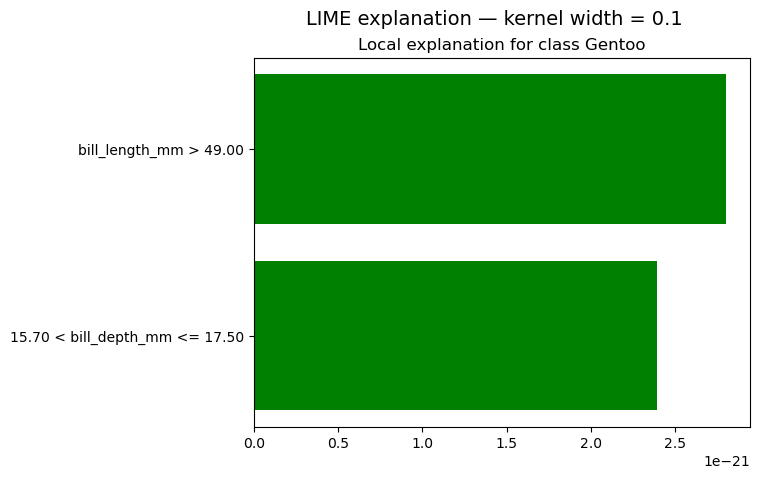

bill_length_mm         50.5
bill_depth_mm          15.9
flipper_length_mm     222.0
body_mass_g          5550.0
Name: 196, dtype: float64
Gentoo


c:\Users\katha\anaconda3\envs\leysin\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\katha\anaconda3\envs\leysin\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


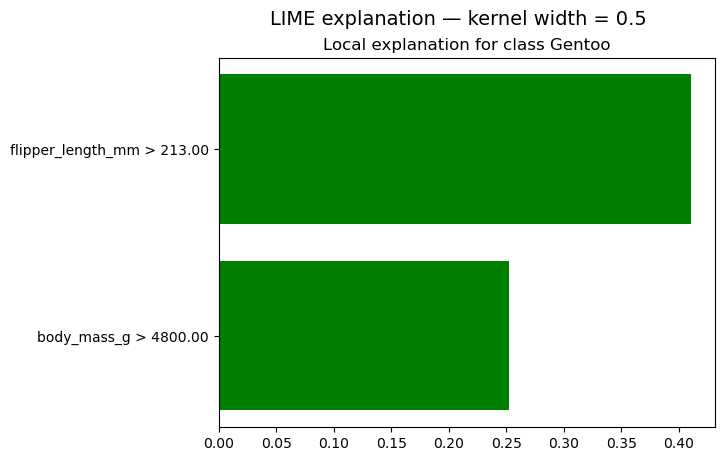

bill_length_mm         50.5
bill_depth_mm          15.9
flipper_length_mm     222.0
body_mass_g          5550.0
Name: 196, dtype: float64
Gentoo


c:\Users\katha\anaconda3\envs\leysin\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\katha\anaconda3\envs\leysin\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


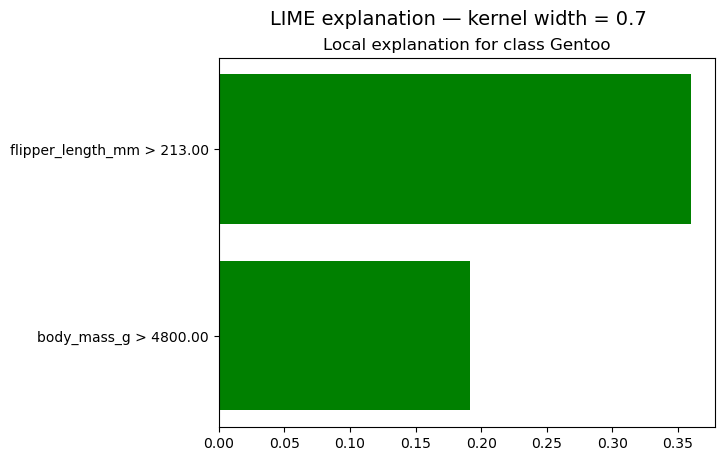

bill_length_mm         50.5
bill_depth_mm          15.9
flipper_length_mm     222.0
body_mass_g          5550.0
Name: 196, dtype: float64
Gentoo


c:\Users\katha\anaconda3\envs\leysin\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\katha\anaconda3\envs\leysin\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


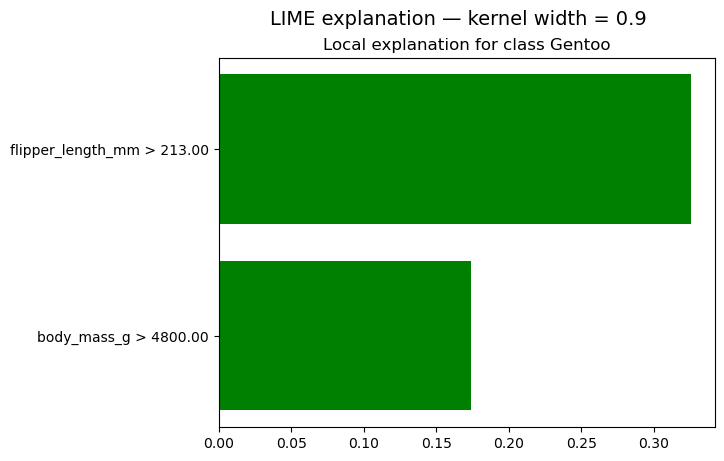

bill_length_mm         50.5
bill_depth_mm          15.9
flipper_length_mm     222.0
body_mass_g          5550.0
Name: 196, dtype: float64
Gentoo


c:\Users\katha\anaconda3\envs\leysin\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\katha\anaconda3\envs\leysin\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


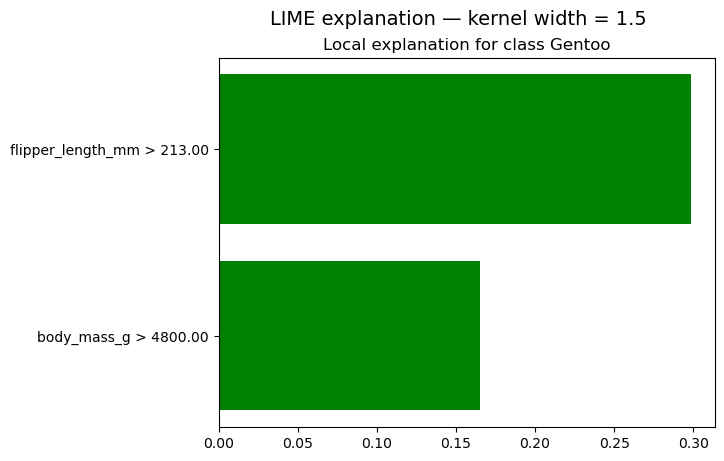

bill_length_mm         50.5
bill_depth_mm          15.9
flipper_length_mm     222.0
body_mass_g          5550.0
Name: 196, dtype: float64
Gentoo


c:\Users\katha\anaconda3\envs\leysin\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\katha\anaconda3\envs\leysin\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


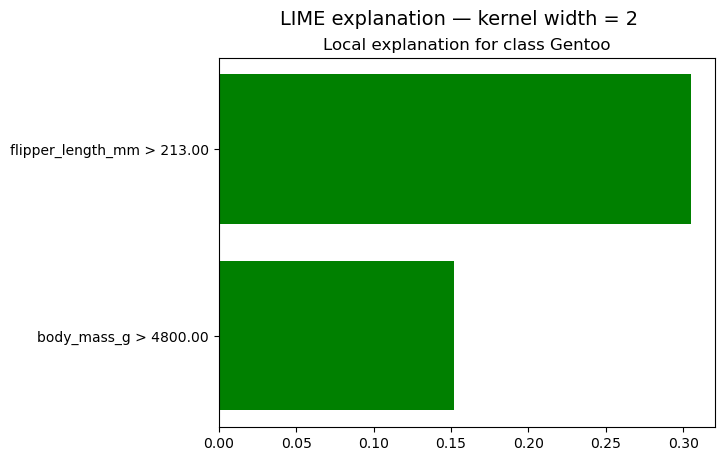

bill_length_mm         50.5
bill_depth_mm          15.9
flipper_length_mm     222.0
body_mass_g          5550.0
Name: 196, dtype: float64
Gentoo


c:\Users\katha\anaconda3\envs\leysin\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\katha\anaconda3\envs\leysin\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


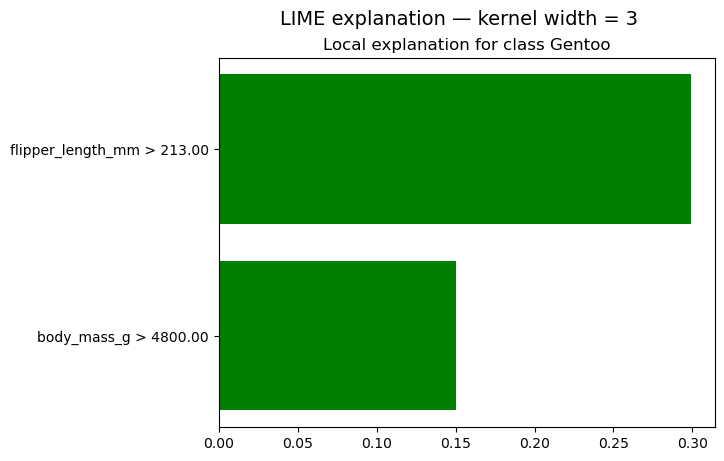

bill_length_mm         50.5
bill_depth_mm          15.9
flipper_length_mm     222.0
body_mass_g          5550.0
Name: 196, dtype: float64
Gentoo


c:\Users\katha\anaconda3\envs\leysin\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\katha\anaconda3\envs\leysin\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


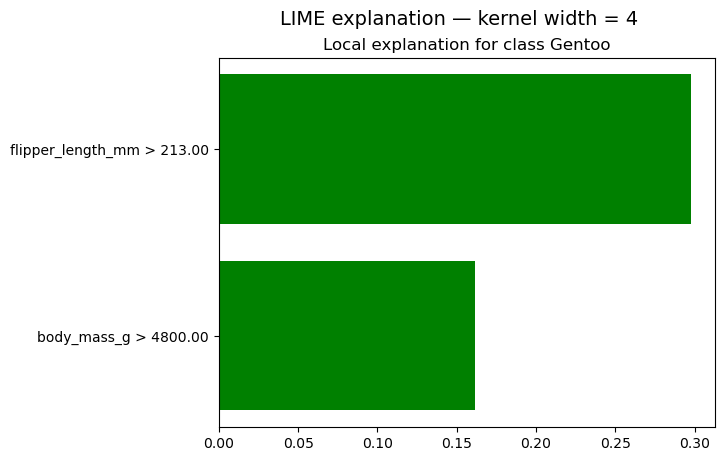

bill_length_mm         50.5
bill_depth_mm          15.9
flipper_length_mm     222.0
body_mass_g          5550.0
Name: 196, dtype: float64
Gentoo


c:\Users\katha\anaconda3\envs\leysin\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\katha\anaconda3\envs\leysin\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


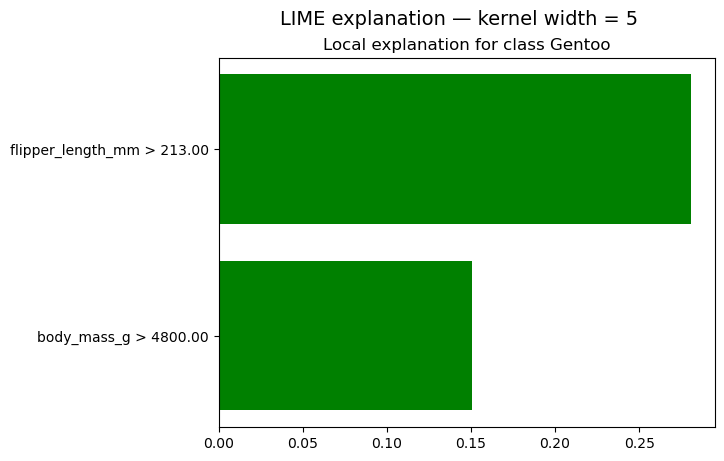

In [54]:
import lime.lime_tabular
import matplotlib.pyplot as plt

class_names = ['Adelie', 'Chinstrap', 'Gentoo']

kernel_widths = [0.1, 0.5, 0.7, 0.9, 1.5, 2, 3, 4, 5]

for k in kernel_widths:

    # Create the LIME explainer
    explainer = lime.lime_tabular.LimeTabularExplainer(
        training_data=X_train.to_numpy(),         # Data LIME uses to generate perturbations
        feature_names=features,   # List of feature names
        class_names=class_names,       # List of class names
        mode='classification',          # Specify 'classification' or 'regression'
        kernel_width=k
        # Optional: discretize_continuous=True, verbose=True, etc.
    )

    # Explain the chosen instance

    instance_idx = 4
    instance_to_explain = X_test.iloc[instance_idx].to_numpy()

    print(X_test.iloc[instance_idx])
    print(Y_test.iloc[instance_idx])

    predicted_class = model.predict(instance_to_explain.reshape(1, -1))[0]
    #print(predicted_class)
    predicted_class_idx = list(model.classes_).index(predicted_class)

    explanation = explainer.explain_instance(
        data_row=instance_to_explain,      # The instance you want to explain
        predict_fn=prediction_function,             # The prediction function defined above
        num_features=2,   # Max number of features in the explanation
        num_samples=5000,                   # Number of samples to generate for perturbation
        top_labels=1                        #(to explain only the top predicted class)
    )
    
    fig = explanation.as_pyplot_figure(
        label=predicted_class_idx
    )

    fig.suptitle(
        f"LIME explanation — kernel width = {k}",
        fontsize=14
    )

    plt.show()
